In [29]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [30]:
# loading dataset

df = pd.read_csv('../data/q3_retail_promotions.csv')

# quick check
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [31]:
# converting date column

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# extracting useful info from date
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# checking month end (simple logic)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [32]:
# sorting data by date (important for time-based split)

df = df.sort_values(by='transaction_date')

In [33]:
# taking last 20% as test data

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

Random split is not suitable because this is time-based data.
If we shuffle, model may learn future information.
So we train on past data and test on recent data.

In [34]:
# separating features and target

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

In [35]:
# categorical columns (given in question)

cat_cols = ['promotion_type', 'location_type', 'store_size']

# rest are numerical
num_cols = [col for col in X_train.columns if col not in cat_cols]

In [36]:
# preprocessing (scaling + encoding)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [37]:
# linear regression pipeline

lr_model = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

# training
lr_model.fit(X_train, y_train)

# predictions
lr_pred = lr_model.predict(X_test)

In [38]:
# random forest pipeline

rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [39]:
# simple evaluation

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print("RMSE:", rmse)
    print("MAE:", mae)

In [40]:
print("Linear Regression")
evaluate(y_test, lr_pred)

print("\nRandom Forest")
evaluate(y_test, rf_pred)

Linear Regression
RMSE: 27.12145116489063
MAE: 21.052926674588395

Random Forest
RMSE: 30.840947138774233
MAE: 24.306125


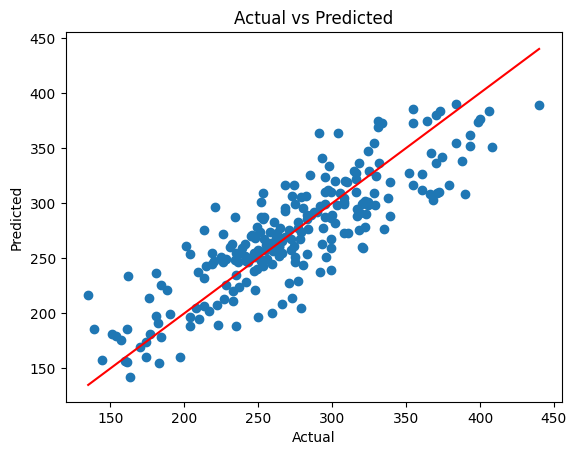

In [41]:
# predicted vs actual

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [42]:
# extracting feature importance

model = rf_model.named_steps['model']
importances = model.feature_importances_

feature_names = rf_model.named_steps['prep'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp.sort_values(by='importance', ascending=False).head(5)

,feature,importance
2,num__is_festival,0.173413
18,cat__store_size_small,0.166752
15,cat__location_type_urban,0.108505
6,num__day_of_week,0.080552
1,num__is_weekend,0.067103


Random Forest performs better than Linear Regression.

It captures complex patterns in data.

Top features include promotion type and competition density.